# EDA

Medidas de Tendencia Central

In [2]:
import pandas as pd
import numpy as np

# Crear un DataFrame de ejemplo con calificaciones de estudiantes
data = {
    'Estudiante': ['Ana', 'Juan', 'Maria', 'Pedro', 'Laura', 'Carlos', 'Sofía', 'Daniel', 'Paula', 'Diego'],
    'Matematicas': [85, 78, 92, 65, 88, 70, 95, 80, 75, 90],
    'Ciencias': [70, 85, 88, 72, 90, 75, 92, 80, 82, 85],
    'Literatura': [90, 80, 75, 85, 92, 70, 88, 90, 78, 85],
    'Genero': ['F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Faltas': [2, 1, 0, 3, 1, 2, 0, 1, 2, 1]
}
df = pd.DataFrame(data)

print("DataFrame Original:")
print(df)

print("\n--- Media (Promedio) de las Calificaciones ---")

# Media de la columna 'Matematicas'
media_matematicas = df['Matematicas'].mean()
print(f"Media de Matemáticas: {media_matematicas:.2f}")

# Media de la columna 'Ciencias'
media_ciencias = df['Ciencias'].mean()
print(f"Media de Ciencias: {media_ciencias:.2f}")

# También puedes calcular la media de todas las columnas numéricas a la vez
media_todas_materias = df[['Matematicas', 'Ciencias', 'Literatura', 'Faltas']].mean()
print("\nMedia de todas las columnas numéricas:")
print(media_todas_materias)

print("\n--- Mediana de las Calificaciones ---")

# Mediana de la columna 'Matematicas'
mediana_matematicas = df['Matematicas'].median()
print(f"Mediana de Matemáticas: {mediana_matematicas:.2f}")

# Mediana de la columna 'Literatura'
mediana_literatura = df['Literatura'].median()
print(f"Mediana de Literatura: {mediana_literatura:.2f}")

# También puedes calcular la mediana de todas las columnas numéricas a la vez
mediana_todas_materias = df[['Matematicas', 'Ciencias', 'Literatura', 'Faltas']].median()
print("\nMediana de todas las columnas numéricas:")
print(mediana_todas_materias)

print("\n--- Moda de las Calificaciones y Género ---")

# Moda de la columna 'Ciencias'
moda_ciencias = df['Ciencias'].mode()
print(f"Moda de Ciencias: {moda_ciencias.tolist()}") # .tolist() para ver los valores si hay múltiples

# Moda de la columna 'Literatura' (puede haber más de una)
moda_literatura = df['Literatura'].mode()
print(f"Moda de Literatura: {moda_literatura.tolist()}")

# Moda de la columna 'Faltas'
moda_faltas = df['Faltas'].mode()
print(f"Moda de Faltas: {moda_faltas.tolist()}")

# Moda de la columna categórica 'Genero'
moda_genero = df['Genero'].mode()
print(f"Moda de Género: {moda_genero.tolist()}")

DataFrame Original:
  Estudiante  Matematicas  Ciencias  Literatura Genero  Faltas
0        Ana           85        70          90      F       2
1       Juan           78        85          80      M       1
2      Maria           92        88          75      F       0
3      Pedro           65        72          85      M       3
4      Laura           88        90          92      F       1
5     Carlos           70        75          70      M       2
6      Sofía           95        92          88      F       0
7     Daniel           80        80          90      M       1
8      Paula           75        82          78      F       2
9      Diego           90        85          85      M       1

--- Media (Promedio) de las Calificaciones ---
Media de Matemáticas: 81.80
Media de Ciencias: 81.90

Media de todas las columnas numéricas:
Matematicas    81.8
Ciencias       81.9
Literatura     83.3
Faltas          1.3
dtype: float64

--- Mediana de las Calificaciones ---
Mediana de M

Cuartiles

DataFrame de Calificaciones:
    Calificacion
0             40
1             65
2             68
3             70
4             72
5             73
6             74
7             75
8             76
9             77
10            78
11            79
12            80
13            81
14            82
15            83
16            84
17            85
18            86
19            87
20            88
21            89
22            90
23            92
24            95

Número de observaciones: 25

Q1 (25%): 74.00
Q2 (50%): 80.00
Q3 (75%): 86.00
IQR: 12.00
Límite inferior para outliers: 56.00
Límite superior para outliers: 104.00

Valores considerados outliers según la regla del 1.5 * IQR:
   Calificacion
0            40


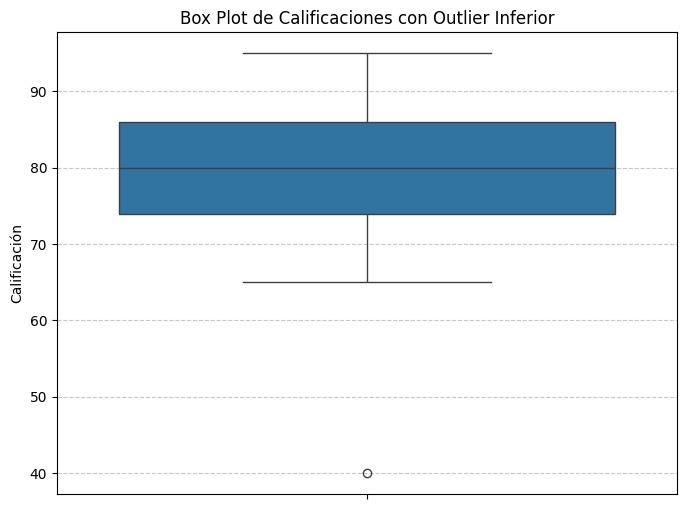

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# La mayoría de los datos estarán entre 65 y 95, aproximadamente
calificaciones_datos = [
    40, 65, 68, 70, 72, 73, 74,
    75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
    86, 87, 88, 89, 90, 92, 95
]

# Crear el DataFrame
df_calificaciones = pd.DataFrame({'Calificacion': calificaciones_datos})

print("DataFrame de Calificaciones:")
print(df_calificaciones)
print(f"\nNúmero de observaciones: {len(df_calificaciones)}")

# --- Calcular Q1, Q3 y el IQR para identificar outliers ---
Q1 = df_calificaciones['Calificacion'].quantile(0.25)
Q2 = df_calificaciones['Calificacion'].quantile(0.5)
Q3 = df_calificaciones['Calificacion'].quantile(0.75)

IQR = Q3 - Q1

lower_bound_outlier = Q1 - 1.5 * IQR #outlier por debajo.
upper_bound_outlier = Q3 + 1.5 * IQR #outlier por encima.

print(f"\nQ1 (25%): {Q1:.2f}")
print(f"Q2 (50%): {Q2:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior para outliers: {lower_bound_outlier:.2f}")
print(f"Límite superior para outliers: {upper_bound_outlier:.2f}")

# Identificar outliers
outliers = df_calificaciones[(df_calificaciones['Calificacion'] < lower_bound_outlier) |
                             (df_calificaciones['Calificacion'] > upper_bound_outlier)]

print("\nValores considerados outliers según la regla del 1.5 * IQR:")
print(outliers)

# --- Visualizar con un Box Plot para confirmar ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_calificaciones['Calificacion'])
plt.title('Box Plot de Calificaciones con Outlier Inferior')
plt.ylabel('Calificación')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Percentiles

In [4]:
%reset -f
import pandas as pd
import numpy as np

# Datos de ejemplo
calificaciones = [60, 65, 70, 72, 75, 80, 85, 88, 90, 92, 95]
df_calificaciones = pd.DataFrame({'Calificacion': calificaciones})

print("DataFrame Original de Calificaciones:")
print(df_calificaciones)
print(f"Número total de datos: {len(df_calificaciones)}")

# --- Usando Pandas ---
# El método .quantile() espera la fracción (0.0 a 1.0)
# Calcular el percentil 70 (0.70)
percentil_70_pandas = df_calificaciones['Calificacion'].quantile(0.70)
print(f"\nPercentil 70 (Pandas): {percentil_70_pandas:.2f}")

# Calcular múltiples percentiles a la vez (ej. P10, P50 (mediana), P90)
multi_percentiles_pandas = df_calificaciones['Calificacion'].quantile([0.10, 0.50, 0.90])
print("\nMúltiples percentiles (Pandas):")
print(multi_percentiles_pandas)

# --- Usando NumPy ---
# El método np.percentile() espera el percentil como un número entero (0 a 100)
percentil_70_numpy = np.percentile(calificaciones, 70)
print(f"\nPercentil 70 (NumPy): {percentil_70_numpy:.2f}")

# Calcular múltiples percentiles con NumPy
multi_percentiles_numpy = np.percentile(calificaciones, [10, 50, 90])
print("\nMúltiples percentiles (NumPy):")
print(multi_percentiles_numpy)

DataFrame Original de Calificaciones:
    Calificacion
0             60
1             65
2             70
3             72
4             75
5             80
6             85
7             88
8             90
9             92
10            95
Número total de datos: 11

Percentil 70 (Pandas): 88.00

Múltiples percentiles (Pandas):
0.1    65.0
0.5    80.0
0.9    92.0
Name: Calificacion, dtype: float64

Percentil 70 (NumPy): 88.00

Múltiples percentiles (NumPy):
[65. 80. 92.]


Histogramas

DataFrame de Salarios (primeras 5 filas):
   Salario_Anual
0   43973.713224
1   38893.885591
2   45181.508305
3   52184.238851
4   38126.773002

Número total de empleados: 1010


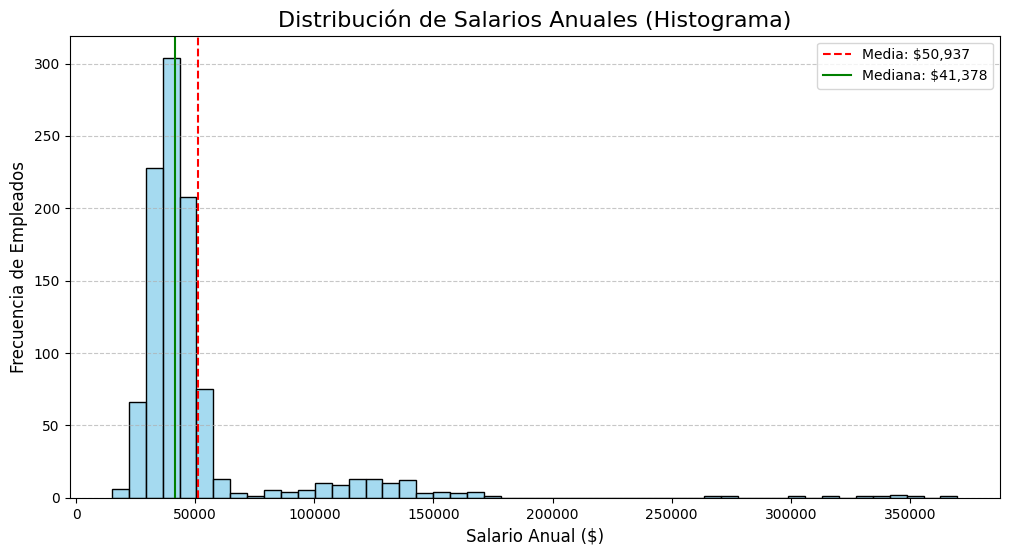

In [5]:
%reset -f
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generar un DataFrame de salarios anuales (reutilizando el ejemplo anterior)
np.random.seed(42) # Para reproducibilidad

salarios_bajos = np.random.normal(loc=40000, scale=8000, size=900)
salarios_altos = np.random.normal(loc=120000, scale=25000, size=100)
salarios_super_altos = np.random.normal(loc=300000, scale=50000, size=10)

salarios = np.concatenate([salarios_bajos, salarios_altos, salarios_super_altos])

#Evitar valores negativos o irrealmente bajos:
salarios = np.maximum(salarios, 15000)

df_salarios = pd.DataFrame({'Salario_Anual': salarios})

print("DataFrame de Salarios (primeras 5 filas):")
print(df_salarios.head())
print(f"\nNúmero total de empleados: {len(df_salarios)}")

# Calcular la media y la mediana para visualizarlas en el histograma
media_salario = df_salarios['Salario_Anual'].mean()
mediana_salario = df_salarios['Salario_Anual'].median()

# --- Crear el Histograma ---
plt.figure(figsize=(12, 6)) # Define el tamaño de la figura

# data: el DataFrame
# x: la columna que queremos graficar
# bins: Número de intervalos o una secuencia de bordes de bin
# color: Color de las barras
#sns.histplot(data=df_salarios, x='Salario_Anual', kde=True, bins=50, color='skyblue')
sns.histplot(data=df_salarios, x='Salario_Anual', bins=50, color='skyblue')

# Añadir líneas para la media y la mediana (opcional, pero útil para EDA)
plt.axvline(media_salario, color='red', linestyle='--', label=f'Media: ${media_salario:,.0f}')
plt.axvline(mediana_salario, color='green', linestyle='-', label=f'Mediana: ${mediana_salario:,.0f}')

# Añadir título y etiquetas a los ejes
plt.title('Distribución de Salarios Anuales (Histograma)', fontsize=16)
plt.xlabel('Salario Anual ($)', fontsize=12)
plt.ylabel('Frecuencia de Empleados', fontsize=12)

# Añadir leyenda y cuadrícula
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

Gráfico de barras

DataFrame de Ventas Original:
       Producto  Ventas_Unidades  Precio_Unitario  Valor_Venta
0        Laptop               10             1200        12000
1    Smartphone               15              800        12000
2        Tablet                8              450         3600
3   Auriculares               25              100         2500
4    Smartwatch               12              250         3000
5        Laptop               18             1200        21600
6        Tablet               10              450         4500
7   Auriculares               20              100         2000
8    Smartphone               17              800        13600
9    Smartwatch               14              250         3500
10       Laptop               22             1200        26400

DataFrame de Ventas Agrupadas por Producto:
      Producto  Valor_Venta
1       Laptop        60000
2   Smartphone        25600
4       Tablet         8100
3   Smartwatch         6500
0  Auriculares         4500


C:\Users\melca\AppData\Local\Temp\ipykernel_195080\2395328021.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Producto', y='Valor_Venta', data=ventas_por_producto, palette='viridis')


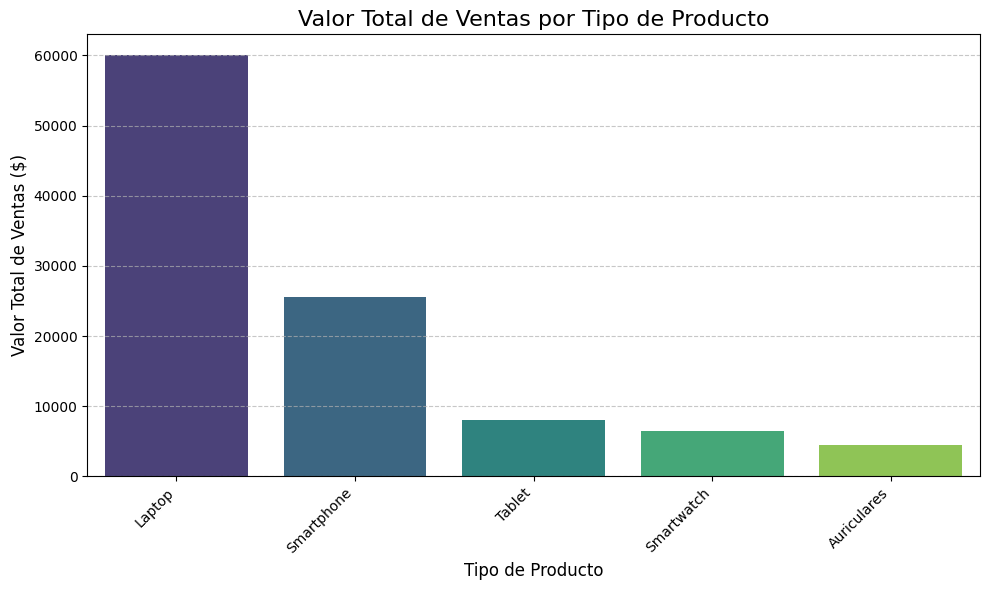

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Lo usaremos para generar datos de ejemplo

# 1. Crear un DataFrame de ejemplo
# Simularemos datos de ventas de diferentes productos
data = {
    'Producto': ['Laptop', 'Smartphone', 'Tablet', 'Auriculares', 'Smartwatch', 'Laptop', 'Tablet', 'Auriculares', 'Smartphone', 'Smartwatch', 'Laptop'],
    'Ventas_Unidades': [10, 15, 8, 25, 12, 18, 10, 20, 17, 14, 22],
    'Precio_Unitario': [1200, 800, 450, 100, 250, 1200, 450, 100, 800, 250, 1200]
}
df_ventas = pd.DataFrame(data)

# Calcular el valor total de ventas por cada transacción
df_ventas['Valor_Venta'] = df_ventas['Ventas_Unidades'] * df_ventas['Precio_Unitario']

print("DataFrame de Ventas Original:")
print(df_ventas)

# 2. Preparar los datos para el gráfico de barras
# Queremos ver el VALOR TOTAL de ventas por cada PRODUCTO.
# Para esto, agrupamos por 'Producto' y sumamos 'Valor_Venta'.
ventas_por_producto = df_ventas.groupby('Producto')['Valor_Venta'].sum().reset_index()

# Opcional: ordenar los productos por el valor total de ventas para una mejor visualización
ventas_por_producto = ventas_por_producto.sort_values(by='Valor_Venta', ascending=False)

print("\nDataFrame de Ventas Agrupadas por Producto:")
print(ventas_por_producto)

# 3. Crear el Gráfico de Barras
plt.figure(figsize=(10, 6)) # Define el tamaño del gráfico

# Usamos sns.barplot() de Seaborn
# x: La columna categórica que queremos representar en el eje X
# y: La columna numérica que queremos que determine la altura de las barras (sumada por defecto)
# palette: Define la paleta de colores para las barras
sns.barplot(x='Producto', y='Valor_Venta', data=ventas_por_producto, palette='viridis')

# 4. Personalizar el Gráfico (Títulos, Etiquetas, etc.)
plt.title('Valor Total de Ventas por Tipo de Producto', fontsize=16)
plt.xlabel('Tipo de Producto', fontsize=12)
plt.ylabel('Valor Total de Ventas ($)', fontsize=12)

# Rotar etiquetas del eje X si los nombres de productos son largos
plt.xticks(rotation=45, ha='right')

# Añadir una cuadrícula al fondo para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar el diseño para asegurar que todo quepa
plt.tight_layout()

# 5. Mostrar el gráfico
plt.show()

Gráficos circulares

DataFrame de Frutas Favoritas:
     Fruta  Votos
0  Manzana     30
1   Banana     25
2  Naranja     15
3      Uva     20
4     Pera     10


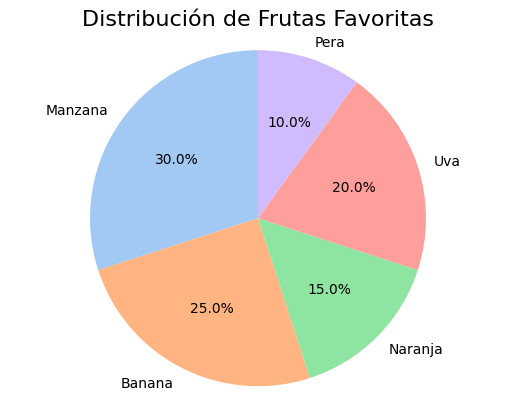

In [7]:



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Incluido por convención, aunque plt.pie es de Matplotlib

# Crear un DataFrame a partir de un diccionario.
# Aquí, los datos ya están en el formato de conteo por categoría
data_frutas = {
    'Fruta': ['Manzana', 'Banana', 'Naranja', 'Uva', 'Pera'],
    'Votos': [30, 25, 15, 20, 10]
}
df_frutas = pd.DataFrame(data_frutas)

print("DataFrame de Frutas Favoritas:")
print(df_frutas)

# Los datos ya están listos para el gráfico circular:
# 'Fruta' serán las etiquetas de los segmentos (labels)
# 'Votos' serán los valores que determinan el tamaño de los segmentos (x)

# plt.pie() es la función de Matplotlib para gráficos circulares
plt.pie(
    df_frutas['Votos'],        # Los valores que determinan el tamaño de cada rebanada
    labels=df_frutas['Fruta'], # Las etiquetas para cada rebanada
    autopct='%1.1f%%',         # Formato para mostrar el porcentaje en cada rebanada (ej. "25.0%")
    startangle=90,             # El ángulo donde comienza la primera rebanada (vertical hacia arriba)
    colors=sns.color_palette('pastel') # Una bonita paleta de colores suaves
)

# 3. Personalizar el Gráfico
plt.title('Distribución de Frutas Favoritas', fontsize=16)
plt.axis('equal') # Asegura que el gráfico sea un círculo perfecto y no una elipse

# 4. Mostrar el gráfico
plt.show()




Gráficos de dispersión

DataFrame de Proyectos (primeras 5 filas):
   Horas_Desarrollo  Errores_Encontrados
0            1333.0                 75.0
1            1782.0                 67.0
2            2266.0                 44.0
3             643.0                 91.0
4            1788.0                 51.0

Número total de proyectos: 120

Coeficiente de Correlación entre Horas de Desarrollo y Errores: -0.591


C:\Users\melca\AppData\Local\Temp\ipykernel_195080\1408264946.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # Muestra la leyenda de la línea de tendencia


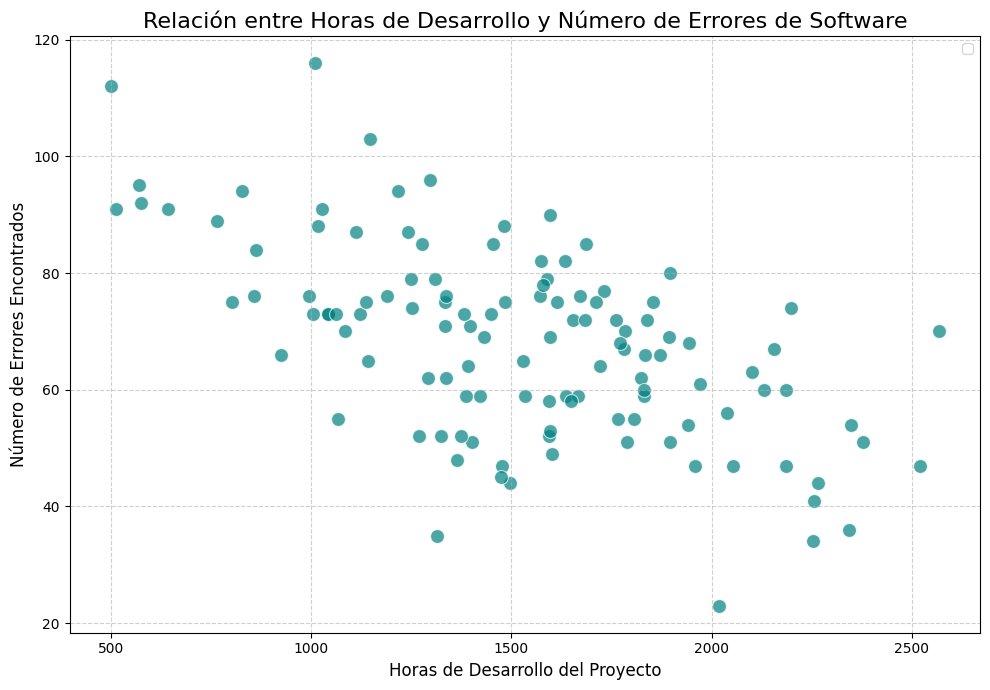

In [8]:
%reset -f

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear un DataFrame de ejemplo
# Simularemos datos de proyectos de software
np.random.seed(29) # Para reproducibilidad

num_proyectos = 120

# Horas de desarrollo por proyecto (simulamos una distribución normal)
horas_desarrollo = np.random.normal(loc=1500, scale=400, size=num_proyectos).round(0)
# Asegurarnos de que las horas no sean negativas o irrealmente bajas
horas_desarrollo = np.maximum(horas_desarrollo, 500)

# Número de errores (bugs)
# Modelamos una relación negativa con las horas, pero con ruido y cierta base de errores
# Cuantas más horas, menos errores base
errores = 100 - (horas_desarrollo / 50) + np.random.normal(loc=0, scale=15, size=num_proyectos)
# Asegurarnos de que los errores no sean negativos
errores = np.maximum(errores, 5).round(0) # Mínimo 5 errores, redondeado

df_proyectos = pd.DataFrame({
    'Horas_Desarrollo': horas_desarrollo,
    'Errores_Encontrados': errores
})

print("DataFrame de Proyectos (primeras 5 filas):")
print(df_proyectos.head())
print(f"\nNúmero total de proyectos: {len(df_proyectos)}")

# 2. Calcular la Correlación (opcional, pero útil para scatter plots)
correlacion = df_proyectos['Horas_Desarrollo'].corr(df_proyectos['Errores_Encontrados'])
print(f"\nCoeficiente de Correlación entre Horas de Desarrollo y Errores: {correlacion:.3f}")


# 3. Crear el Gráfico de Dispersión
plt.figure(figsize=(10, 7)) # Definimos el tamaño del gráfico

# Usamos sns.scatterplot()
# x: Horas de Desarrollo (variable independiente)
# y: Errores Encontrados (variable dependiente)
# data: El DataFrame con nuestros datos
# hue: Podemos añadir otra dimensión, por ejemplo, colorear por un rango de errores (esto es solo para visualización)
#sns.scatterplot(x='Horas_Desarrollo', y='Errores_Encontrados', data=df_proyectos,
 #                    hue=pd.cut(df_proyectos['Errores_Encontrados'], bins=3, labels=['Bajo', 'Medio', 'Alto']),
  #                   size='Horas_Desarrollo', sizes=(50, 500), alpha=0.7, palette='coolwarm')
# No usaremos hue/size para mantenerlo más sencillo en el gráfico, solo x, y y data.
sns.scatterplot(x='Horas_Desarrollo', y='Errores_Encontrados', data=df_proyectos,
                color='teal', alpha=0.7, s=100) # s es el tamaño del punto


# Opcional: Añadir una línea de regresión para visualizar la tendencia
# sns.regplot(x='Horas_Desarrollo', y='Errores_Encontrados', data=df_proyectos,
            # scatter=False, color='red', line_kws={'linestyle':'--'}, label='Línea de Tendencia')


# 4. Personalizar el Gráfico
plt.title('Relación entre Horas de Desarrollo y Número de Errores de Software', fontsize=16)
plt.xlabel('Horas de Desarrollo del Proyecto', fontsize=12)
plt.ylabel('Número de Errores Encontrados', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Muestra la leyenda de la línea de tendencia

# 5. Mostrar el gráfico
plt.tight_layout() # Ajusta el diseño para evitar recortes
plt.show()

Mapas de calor

DataFrame de Ventas por Día y Producto:
           Laptops  Smartphones  Tablets
Lunes            5           10        3
Martes           2            7        1
Miércoles        8           12        5
Jueves           4            9        2
Viernes          6           11        4


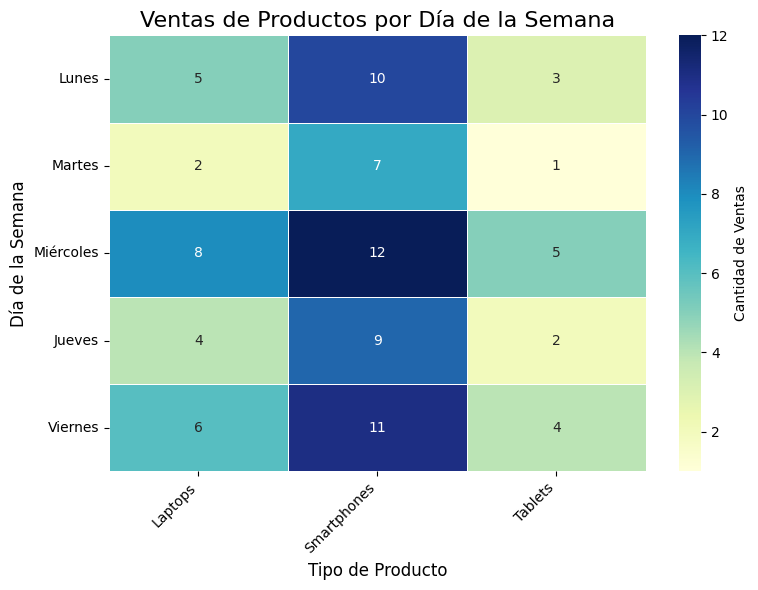

In [9]:
%reset -f

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear un DataFrame de ejemplo muy simple
# Este DataFrame ya está en el formato de "matriz" que necesita un mapa de calor.
# Las filas son los días, las columnas los productos, y los valores son las ventas.
data_ventas_diarias = {
    'Laptops': [5, 2, 8, 4, 6],
    'Smartphones': [10, 7, 12, 9, 11],
    'Tablets': [3, 1, 5, 2, 4]
}
# Creamos el DataFrame y le asignamos los días de la semana como índice
df_ventas_por_dia = pd.DataFrame(data_ventas_diarias,
                                 index=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'])

print("DataFrame de Ventas por Día y Producto:")
print(df_ventas_por_dia)

# 2. Crear el Mapa de Calor
plt.figure(figsize=(8, 6)) # Ajustamos el tamaño para una buena visualización

# sns.heatmap() es la función clave
# data: El DataFrame que ya está en el formato de matriz deseado
# annot=True: Muestra los valores numéricos en cada celda
# cmap: La paleta de colores. 'YlGnBu' (Yellow-Green-Blue) es buena para valores ascendentes.
# fmt='g': Formato de los números (general, sin decimales para conteos enteros)
# linewidths=.5: Añade un pequeño borde blanco entre las celdas
# cbar_kws={'label': 'Cantidad de Ventas'}: Etiqueta para la barra de color lateral
sns.heatmap(df_ventas_por_dia,
            annot=True,
            cmap='YlGnBu',
            fmt='g',
            linewidths=.5,
            cbar_kws={'label': 'Cantidad de Ventas'})

# 3. Personalizar el Gráfico
plt.title('Ventas de Productos por Día de la Semana', fontsize=16)
plt.xlabel('Tipo de Producto', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.xticks(rotation=45, ha='right') # Opcional: rotar etiquetas si se superponen
plt.yticks(rotation=0)
plt.tight_layout() # Ajusta el diseño para evitar que los elementos se superpongan

# 4. Mostrar el gráfico
plt.show()

Gráficos de radar

DataFrame de Habilidades de los Equipos:
                         Equipo Alfa  Equipo Beta  Equipo Gamma
Habilidad                                                      
Python                             8            7             6
SQL                                7            9             6
Cloud                              9            6             7
Comunicación                       6            8             9
Resolución de Problemas            7            8             9
Trabajo en Equipo                  8            7             9


C:\Users\melca\AppData\Local\Temp\ipykernel_195080\2179202996.py:47: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, valores_alfa, 'o-', linewidth=2, linestyle='solid', label='Equipo Alfa', color='blue')
C:\Users\melca\AppData\Local\Temp\ipykernel_195080\2179202996.py:50: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, valores_beta, 'o-', linewidth=2, linestyle='solid', label='Equipo Beta', color='green')
C:\Users\melca\AppData\Local\Temp\ipykernel_195080\2179202996.py:53: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(angles, valores_gamma, 'o-', linewidth=2, linestyle='solid', labe

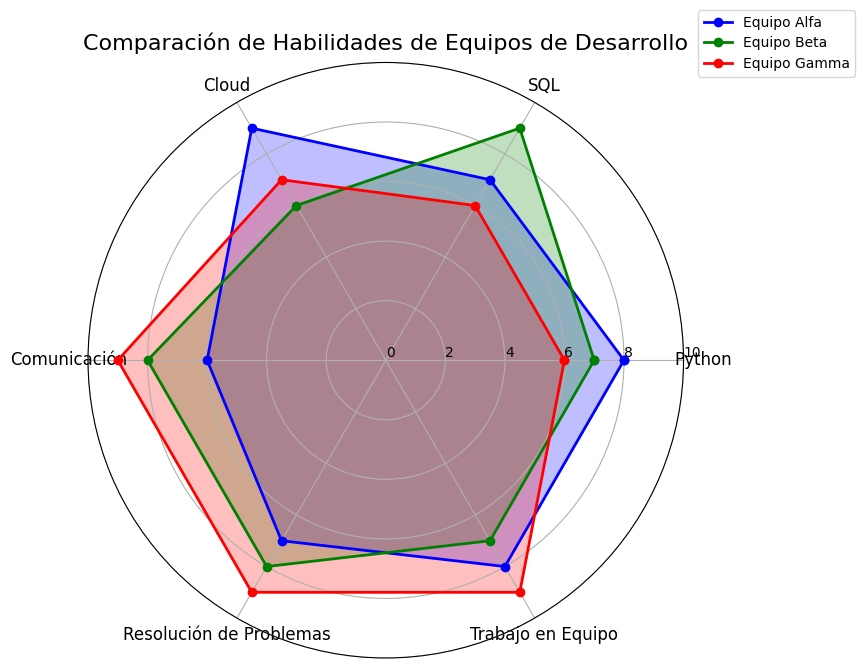

In [10]:
%reset -f

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear el DataFrame de ejemplo
data = {
    'Habilidad': ['Python', 'SQL', 'Cloud', 'Comunicación', 'Resolución de Problemas', 'Trabajo en Equipo'],
    'Equipo Alfa': [8, 7, 9, 6, 7, 8],
    'Equipo Beta': [7, 9, 6, 8, 8, 7],
    'Equipo Gamma': [6, 6, 7, 9, 9, 9]
}
df_habilidades = pd.DataFrame(data)

# Establecer la columna 'Habilidad' como índice para facilitar la transposición
df_habilidades = df_habilidades.set_index('Habilidad')

print("DataFrame de Habilidades de los Equipos:")
print(df_habilidades)

# 2. Preparar los datos para el gráfico de araña
# Las "Habilidades" serán nuestros ejes radiales (variables).
habilidades = df_habilidades.index.tolist()
num_habilidades = len(habilidades)

# Calcular el ángulo para cada eje radial
# Sumamos el primer ángulo al final para cerrar el polígono en el gráfico
angles = np.linspace(0, 2 * np.pi, num_habilidades, endpoint=False).tolist()
angles += angles[:1] # Esto es clave para que el polígono se cierre

# Extraer los datos para cada equipo.
valores_alfa = df_habilidades['Equipo Alfa'].tolist()
valores_alfa += valores_alfa[:1]

valores_beta = df_habilidades['Equipo Beta'].tolist()
valores_beta += valores_beta[:1]

valores_gamma = df_habilidades['Equipo Gamma'].tolist()
valores_gamma += valores_gamma[:1]

# 3. Crear el Gráfico de Araña
plt.figure(figsize=(9, 9)) # Ajusta el tamaño de la figura para un buen círculo
ax = plt.subplot(111, polar=True) # Creamos un subplot con proyección polar

# Dibujar cada polígono para cada equipo
ax.plot(angles, valores_alfa, 'o-', linewidth=2, linestyle='solid', label='Equipo Alfa', color='blue')
ax.fill(angles, valores_alfa, color='blue', alpha=0.25) # Rellena el área para mejor visualización

ax.plot(angles, valores_beta, 'o-', linewidth=2, linestyle='solid', label='Equipo Beta', color='green')
ax.fill(angles, valores_beta, color='green', alpha=0.25)

ax.plot(angles, valores_gamma, 'o-', linewidth=2, linestyle='solid', label='Equipo Gamma', color='red')
ax.fill(angles, valores_gamma, color='red', alpha=0.25)

# 4. Personalizar el Gráfico
# Establecer los ticks para los ejes radiales (la escala)
ax.set_rticks(np.arange(0, 11, 2)) # Ticks en 0, 2, 4, 6, 8, 10
ax.set_rlabel_position(0) # Posición de las etiquetas de la escala
ax.set_rlim(0, 10) # Rango de la escala de 0 a 10

# Establecer las etiquetas de las habilidades en los ejes
ax.set_xticks(angles[:-1]) # Establecer la posición de las etiquetas
ax.set_xticklabels(habilidades, fontsize=12) # Asignar los nombres de las habilidades

# Añadir título y leyenda
plt.title('Comparación de Habilidades de Equipos de Desarrollo', va='bottom', fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1)) # Posicionar la leyenda fuera del gráfico

# Mostrar el gráfico
plt.tight_layout()
plt.show()



Series de tiempo

DataFrame de Precios de Acciones (primeras 5 filas):
            Precio_Cierre   Volumen
Fecha                              
2024-01-01         152.48  127761.0
2024-01-02         149.59   97816.0
2024-01-03         153.80   93962.0
2024-01-04         158.45  125494.0
2024-01-05         149.95  110526.0

Número total de días: 180


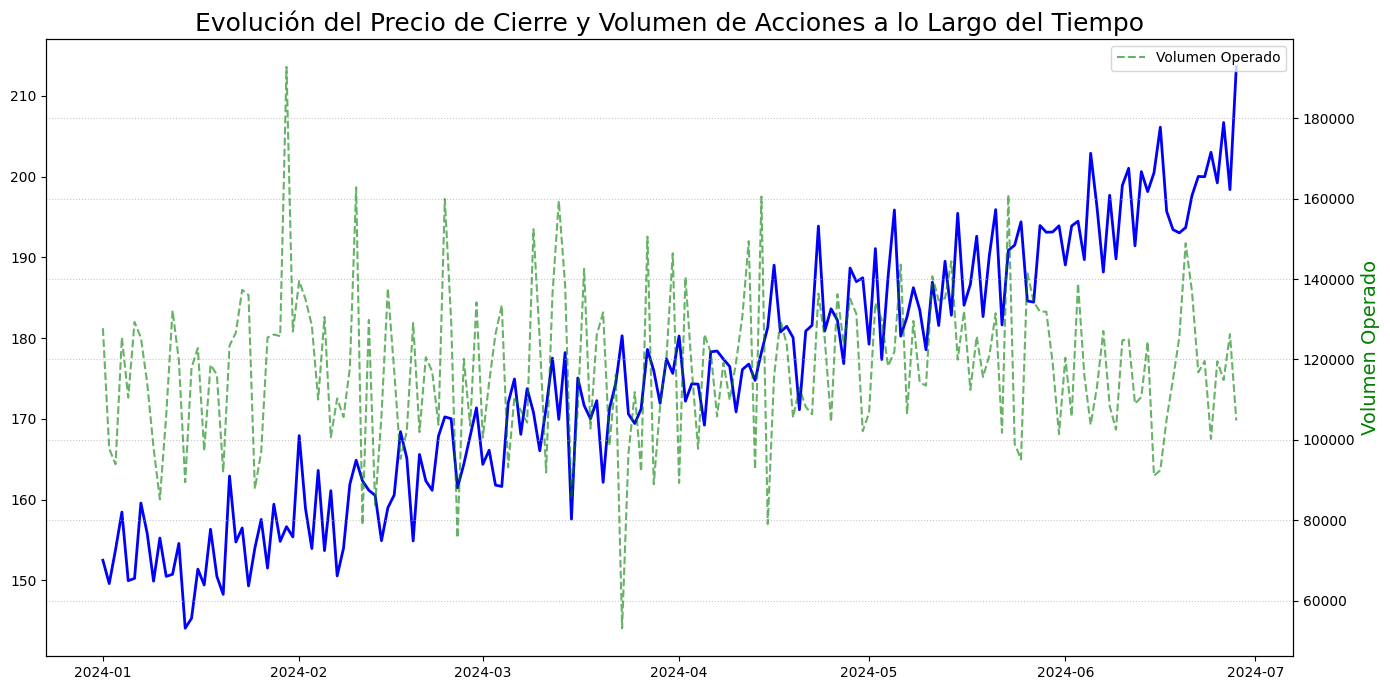

In [11]:
%reset -f

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Crear un DataFrame de ejemplo con datos de series de tiempo
np.random.seed(42) # Para reproducibilidad

# Generar un rango de fechas
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(180)] # 180 días (aprox. 6 meses)

# Simular precios de acciones con una tendencia al alza y algo de ruido
precio_base = 150.0
tendencia = np.linspace(0, 50, len(dates)) # Tendencia creciente a lo largo del tiempo
ruido = np.random.normal(0, 5, len(dates)) # Fluctuaciones diarias
precios = precio_base + tendencia + ruido
precios = np.maximum(precios, 140).round(2) # Asegurar que no bajen mucho, redondear a 2 decimales

# Simular volumen de operaciones (con más volumen en precios más altos, quizás)
volumen_base = 100000
volumen_variacion = np.random.normal(0, 20000, len(dates))
volumen = (volumen_base + volumen_variacion + (precios * 100)).round(0)
volumen = np.maximum(volumen, 50000) # Asegurar un volumen mínimo

df_acciones = pd.DataFrame({
    'Fecha': dates,
    'Precio_Cierre': precios,
    'Volumen': volumen
})

# Establecer la columna 'Fecha' como el índice del DataFrame. Esto es crucial para series de tiempo en Pandas.
df_acciones = df_acciones.set_index('Fecha')

print("DataFrame de Precios de Acciones (primeras 5 filas):")
print(df_acciones.head())
print(f"\nNúmero total de días: {len(df_acciones)}")

# 2. Crear el Gráfico de Series de Tiempo
plt.figure(figsize=(14, 7)) # Tamaño de la figura para una buena visualización

# Gráfico para Precio de Cierre
plt.plot(df_acciones.index, df_acciones['Precio_Cierre'], label='Precio de Cierre ($)', color='blue', linewidth=2)

# Gráfico para Volumen (usando un segundo eje Y para escalas diferentes)
# Esto es común cuando las unidades de las variables son muy distintas.
ax2 = plt.gca().twinx() # Crea un segundo eje Y que comparte el mismo eje X
ax2.plot(df_acciones.index, df_acciones['Volumen'], label='Volumen Operado', color='green', linestyle='--', alpha=0.6)


# 3. Personalizar el Gráfico
plt.title('Evolución del Precio de Cierre y Volumen de Acciones a lo Largo del Tiempo', fontsize=18)
plt.xlabel('Fecha', fontsize=14)

# Etiquetas para los dos ejes Y
plt.ylabel('Precio de Cierre ($)', fontsize=14, color='blue')
ax2.set_ylabel('Volumen Operado', fontsize=14, color='green')

# Configurar leyendas para ambos ejes
plt.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.grid(True, linestyle=':', alpha=0.7) # Añadir una cuadrícula

# Formatear el eje X para mostrar las fechas de forma legible
plt.xticks(rotation=45, ha='right')

# 4. Mostrar el gráfico
plt.tight_layout() # Ajusta el diseño para evitar superposiciones
plt.show()



**EDA automático**

In [12]:
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install ipywidgets
import pandas as pd
from ydata_profiling import ProfileReport

# 1. Cargar los datos
# Usaremos un dataset de ejemplo de internet
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Generar el reporte
profile = ProfileReport(df, title="Reporte de EDA Automático - Titanic")

# 3. Ver el reporte
profile.to_notebook_iframe()

# O si prefieres guardarlo como un archivo independiente:
profile.to_file("mi_analisis_exploratorio.html")

c:\Users\melca\Documents\Universidad 2026-1\Fundamentos Aprendizaje Automatico\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'ipywidgets'